<div style="background:#1F3864;color:white;padding:14px 18px;border-radius:6px"><b>INTERNATIONAL UNIVERSITY – VNU-HCM · SCHOOL OF COMPUTER SCIENCE AND ENGINEERING</b><br>IT149IU · Fundamentals of Programming (Python)</div>

# Lab 2: Loops and Numerical Algorithms

*for / while loops, range(), lists, integer arithmetic (//, %), simple functions and formatted tables*

**Duration:** 150 minutes (3 periods) · **Runs on:** Google Colab, Jupyter Notebook/Lab, VS Code, PyCharm

**How to use this notebook:** read each text cell, run the example cells with **Shift + Enter**, and write your solutions in the cells marked ✍️. Save a copy to your Drive first (*File → Save a copy in Drive*).

> **Legend:** black = original lab content · <font color="#C00000">red = content added in this revision</font>.

In [1]:
# Student information – fill in and run this cell first
STUDENT_NAME = "Nguyễn Anh Tú"
STUDENT_ID   = "ITDSIU23026"
CLASS_GROUP  = "IT149IU – Group 01"
print(f"Lab 2 | {STUDENT_NAME} | {STUDENT_ID} | {CLASS_GROUP}")

Lab 2 | Nguyễn Anh Tú | ITDSIU23026 | IT149IU – Group 01


# 4. Guided Tasks (worked examples)

Each task below gives the goal, the pseudocode and a working **code example**. Run it, study it, then complete the **extended exercises** in the work areas.

## Task 1: Weekly Flu Counts

### Goals

Collect flu case counts for 7 days using a loop, compute **total**, **average**, **minimum**, and **maximum**, and print a formatted weekly summary.

### Learning objectives

- Use `for`/`range()` to iterate over daily inputs.
- Store inputs in a list and calculate total, average, min, max, and rolling mean.
- Find the day with the highest and lowest values using `enumerate`/`index`.
- Extend: use built-in functions in pandas to calculate the statistics.

### Pseudocode / steps

1. Initialize or input data: use a sample list or loop input.
2. Validate input (non-negative integer).
3. Compute total, average, min, max.
4. Print results in a formatted table and text summary.
5. Modify the code to compute the rolling mean.

### Code example

In [ ]:
# Example: sample dataset
counts = [19, 22, 25, 18, 20, 24, 21]
total, avg = sum(counts), sum(counts) / len(counts)
print('total:', total, 'avg:', round(avg, 2), 'min:', min(counts), 'max:', max(counts))

total: 149 avg: 21.29 min: 18 max: 25


In [7]:
# Optional input loop version
counts = []
for d in range(7):
    val = int(input(f'Enter flu cases for day {d}: '))
    counts.append(val)

print('Total:', sum(counts), 'Average:', round(sum(counts) / len(counts), 2))

Total: 149 Average: 21.29


<font color="#C00000">**Worked example – validation, peak day and 3-day rolling mean.**</font>

In [ ]:
# [ADDED] worked example – run this cell
counts = [19, 22, 25, 18, 20, 24, 21]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

peak = counts.index(max(counts))
low = counts.index(min(counts))
print(f"{'Day':<5}{'Cases':>6}")
for day, c in zip(days, counts):
    print(f"{day:<5}{c:>6}")
print(f"Highest: {days[peak]} ({counts[peak]})   Lowest: {days[low]} ({counts[low]})")

rolling = []
for i in range(2, len(counts)):
    rolling.append(round((counts[i - 2] + counts[i - 1] + counts[i]) / 3, 2))
print("3-day rolling mean:", rolling)

In [ ]:
# [ADDED] worked example – run this cell
# Input validation: repeat until the user types a non-negative integer
def read_count(prompt):
    while True:
        text = input(prompt)
        if text.isdigit():          # only digits -> non-negative integer
            return int(text)
        print("  Please enter a non-negative integer.")

### Extended exercises

1. Use pandas to convert the list into a Series and call `.describe()` to get a statistical summary.
2. Plot the 3-day rolling mean of the counts with matplotlib.
3. Detect anomalies where cases differ from the mean by more than 2 × standard deviation.
4. Compare this week's data with the previous week and compute the percent change.
5. Save results to a CSV file using `csv.writer()`.

In [ ]:
# 1
import pandas as pd

counts = [19, 22, 25, 18, 20, 24, 21]
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

total = sum(counts)
avg = sum(counts) / len(counts)
print('Total:', total, 'Avg:', round(avg, 2), 'Min:', min(counts), 'Max:', max(counts))

series_counts = pd.Series(counts)
print(series_counts.describe())

Total: 149 Avg: 21.29 Min: 18 Max: 25
count     7.000000
mean     21.285714
std       2.563480
min      18.000000
25%      19.500000
50%      21.000000
75%      23.000000
max      25.000000
dtype: float64


3-day rolling mean: [22.0, 21.67, 21.0, 20.67, 21.67]


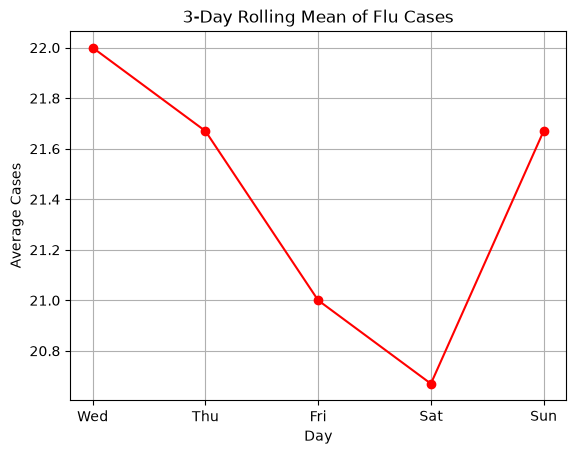

In [ ]:
# 2
import matplotlib.pyplot as plt

rolling = []
for i in range(2, len(counts)):
    rolling.append(round((counts[i-2] + counts[i-1] + counts[i]) / 3, 2))
print("3-day rolling mean:", rolling)

plt.plot(days[2:], rolling, marker='o', linestyle='-', color='red')
plt.title('3-Day Rolling Mean of Flu Cases')
plt.xlabel('Day')
plt.ylabel('Average Cases')
plt.grid(True)
plt.show() 


In [14]:
# 3
mean_val = series_counts.mean()
std_dev = series_counts.std()

print(f"Mean: {mean_val:.2f}, Std Dev: {std_dev:.2f}")
print("Anomalies (> 2 std dev from mean):")

anomaly_found = False
for day, count in zip(days, counts):
    if abs(count - mean_val) > 2 * std_dev:
        print(f"{day}: {count} cases")
        anomaly_found = True

if not anomaly_found:
    print("No anomalies detected this week.")

Mean: 21.29, Std Dev: 2.56
Anomalies (> 2 std dev from mean):
No anomalies detected this week.


In [15]:
# 4
prev_counts = [15, 18, 20, 19, 17, 22, 18] # Assumed previous week data

print(f"{'Day':<5}{'Prev':>6}{'Curr':>6}{'% Change':>12}")
print("-" * 30)
for d, p, c in zip(days, prev_counts, counts):
    pct_change = ((c - p) / p) * 100
    print(f"{d:<5}{p:>6}{c:>6}{pct_change:>11.2f}%")

Day    Prev  Curr    % Change
------------------------------
Mon      15    19      26.67%
Tue      18    22      22.22%
Wed      20    25      25.00%
Thu      19    18      -5.26%
Fri      17    20      17.65%
Sat      22    24       9.09%
Sun      18    21      16.67%


In [16]:
#  5
import csv

filename = "flu_counts.csv"
with open(filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["Day", "Cases"]) 
    for day, count in zip(days, counts):
        writer.writerow([day, count])

print(f"Successfully saved data to {filename}")

Successfully saved data to flu_counts.csv


> 🎓 **Scholar discussion** — **Notes**
>
> This task reflects an early version of time-series data collection and descriptive analytics. Functions like `sum()`/`len()`/`min()`/`max()` parallel vectorized pandas operations, while rolling mean and anomaly detection introduce concepts used in forecasting models (ARIMA, exponential smoothing).
>

> ⚠️ **Common mistakes**
>
> - Forgetting to convert `input()` to `int` → concatenation instead of arithmetic.
> - Using `index()` when duplicates exist (returns only the first index).
> - Not rounding averages or handling division precision properly.
>

## Task 2: Iterative H–M–S Peeling with // and %

### Goals

Convert a total number of seconds into hours, minutes, and seconds using **floor division** (`//`) and **modulus** (`%`).

### Learning objectives

- Use `//` and `%` operators to decompose time into H–M–S.
- Write pseudocode that reflects iterative decomposition logic.
- Understand quotient vs remainder operations.
- Extend the logic to other unit conversions (e.g., milliseconds, dollars/cents).

### Theory

Floor division (`//`) gives the integer quotient of a division, while modulus (`%`) gives the remainder. They are often used together to break down quantities like seconds → hours–minutes–seconds. This "peeling" approach is common in modular arithmetic and digital systems.

### Pseudocode

```text
START
SET secs = total number of seconds
COMPUTE hours = secs // 3600
COMPUTE remainder1 = secs % 3600
COMPUTE minutes = remainder1 // 60
COMPUTE seconds = remainder1 % 60
DISPLAY hours, minutes, seconds
END
```

### Code example

In [ ]:
secs = 9876  # total seconds
h = secs // 3600
rem = secs % 3600
m = rem // 60
s = rem % 60
print(f"{h} hours - {m} minutes - {s} seconds")

<font color="#C00000">*(added)*</font>
```text
2 hours - 44 minutes - 36 seconds
```

### Extended exercises

1. Ask the user to input the total seconds.
2. Format as HH:MM:SS using an f-string: `print(f"{h:02d}:{m:02d}:{s:02d}")`.
3. Verify by converting back: `total_check = h*3600 + m*60 + s`.
4. Extend to milliseconds → hours–minutes–seconds–milliseconds.
5. <font color="#C00000">Peel with a **loop**: use the list of units `[("day", 86400), ("hour", 3600), ("minute", 60), ("second", 1)]` and print e.g. `1 day 3 hours 46 minutes 40 seconds` for 100000 s.</font>

In [17]:
# 1
secs = int(input("Enter total seconds: "))

h = secs // 3600
rem = secs % 3600
m = rem // 60
s = rem % 60

In [18]:
# 2
print(f"Time: {h:02d}:{m:02d}:{s:02d}")

Time: 01:04:35


In [19]:
# 3
total_check = h * 3600 + m * 60 + s
print(f"Verification: {total_check} == {secs} is {total_check == secs}")

Verification: 3875 == 3875 is True


In [20]:
# 4
total_ms = int(input("Enter total milliseconds: "))

ms = total_ms % 1000
remaining_secs = total_ms // 1000

h = remaining_secs // 3600
rem = remaining_secs % 3600
m = rem // 60
s = rem % 60

print(f"{h} hours - {m} minutes - {s} seconds - {ms} milliseconds")

2 hours - 44 minutes - 36 seconds - 123 milliseconds


In [21]:
# 5
secs_to_peel = 100000
units = [("day", 86400), ("hour", 3600), ("minute", 60), ("second", 1)]

print(f"For {secs_to_peel} s:")
rem = secs_to_peel

for name, factor in units:
    value = rem // factor
    rem = rem % factor  # Update remainder for the next iteration
    
    if value > 0: # Add 's' for plural simply to match grammar
        print(f"{value} {name}s", end=" ")

For 100000 s:
1 days 3 hours 46 minutes 40 seconds 

> ⚠️ **Common mistakes**
>
> - Using `/` instead of `//` → results in float division.
> - Forgetting to store the remainder before the next division step.
> - Reversing the operation order, leading to incorrect minutes/seconds.
>

## Task 3: Wage Growth per Year (1–10) with 3% Raise

### Goals

Simulate a yearly wage increase with a constant growth rate of 3%. Use a for loop to compute wages for 10 years and display the results in a formatted table.

### Learning objectives

- Apply the compound growth formula w = o × (1 + p)ⁿ.
- Use for-loop iteration to calculate results over multiple years.
- Format tabular output using f-strings and rounding.
- Understand the relationship between compound rate and exponential growth.

### Theory

The compound growth formula models repeated percentage increases over time: w = o(1 + p)ⁿ, where o is the initial wage, p the growth rate, and n the year number. This exponential pattern is used in finance, salary projections, and data modeling.

### Pseudocode

```text
START
SET o = 10.0      # starting wage
SET p = 0.03      # 3% annual raise
FOR each year n from 1 to 10:
    COMPUTE w = o * (1 + p)^n
    PRINT n, w rounded to 2 decimals
END
```

### Python code

In [27]:
o, p = 10.0, 0.03

print(f"{'Year':<6}{'Wage ($/hr)':>12}")
for n in range(1, 11):
    w = o * (1 + p) ** n
    print(f"{n:<6}{round(w, 2):>12}")

Year   Wage ($/hr)
1             10.3
2            10.61
3            10.93
4            11.26
5            11.59
6            11.94
7             12.3
8            12.67
9            13.05
10           13.44


```text
Year   Wage ($/hr)
1            10.3
2           10.61
3           10.93
4           11.26
5           11.59
6           11.94
7            12.3
8           12.67
9           13.05
10          13.44
```

<font color="#C00000">*Correction:* the sample output now matches the program exactly (years 4 and 10 are 11.26 and 13.44). Tip: `f"{w:>12.2f}"` prints 10.30 instead of 10.3.</font>

### Extended exercises

1. Allow user input for o, p, and the number of years.
2. Add a column showing the increase each year (difference from the previous year).
3. Plot the wage growth curve using matplotlib.
4. Compare multiple rates (2%, 5%, 8%) on the same graph.
5. Adjust for inflation by subtracting an annual 2% rate to compute the real wage.

In [28]:
# 1
o = float(input("Enter starting wage (e.g., 10.0): "))
p = float(input("Enter annual growth rate (e.g., 0.03 for 3%): "))
years = int(input("Enter number of years: "))

print(f"{'Year':<6}{'Wage ($/hr)':>12}")
print("-" * 18)
for n in range(1, years + 1):
    w = o * (1 + p) ** n
    print(f"{n:<6}{w:>12.2f}")

Year   Wage ($/hr)
------------------
1            10.30
2            10.61
3            10.93
4            11.26
5            11.59
6            11.94
7            12.30
8            12.67
9            13.05
10           13.44


In [29]:
# 2
o, p = 10.0, 0.03
prev_w = o  # Keep track of previous year's wage

print(f"{'Year':<6}{'Wage ($/hr)':>12}{'Increase':>12}")
print("-" * 30)
for n in range(1, 11):
    w = o * (1 + p) ** n
    increase = w - prev_w
    print(f"{n:<6}{w:>12.2f}{increase:>12.2f}")
    prev_w = w  # Update for next iteration

Year   Wage ($/hr)    Increase
------------------------------
1            10.30        0.30
2            10.61        0.31
3            10.93        0.32
4            11.26        0.33
5            11.59        0.34
6            11.94        0.35
7            12.30        0.36
8            12.67        0.37
9            13.05        0.38
10           13.44        0.39


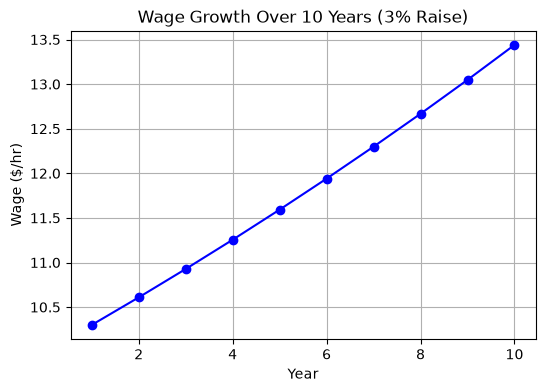

In [30]:
# 3
import matplotlib.pyplot as plt

o, p = 10.0, 0.03
years_list = list(range(1, 11))
wages = []

for n in years_list:
    wages.append(o * (1 + p) ** n)

plt.figure(figsize=(6, 4))
plt.plot(years_list, wages, marker='o', color='blue')
plt.title('Wage Growth Over 10 Years (3% Raise)')
plt.xlabel('Year')
plt.ylabel('Wage ($/hr)')
plt.grid(True)
plt.show()

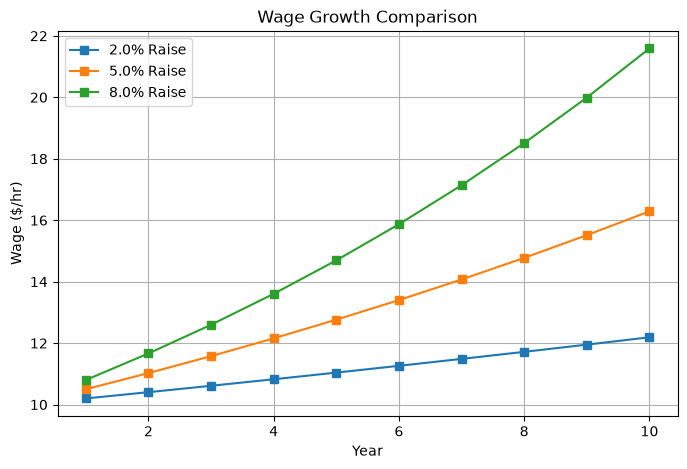

In [32]:
# 4
rates = [0.02, 0.05, 0.08]
o = 10.0

plt.figure(figsize=(8, 5))
for rate in rates:
    wages_at_rate = [o * (1 + rate) ** n for n in years_list]
    plt.plot(years_list, wages_at_rate, marker='s', label=f'{rate*100}% Raise')

plt.title('Wage Growth Comparison')
plt.xlabel('Year')
plt.ylabel('Wage ($/hr)')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# 5
o = 10.0
p = 0.03
inflation_rate = 0.02
real_growth_rate = p - inflation_rate

print(f"{'Year':<6}{'Nominal':>12}{'Real Wage':>12}")
print("-" * 30)
for n in range(1, 11):
    nominal_w = o * (1 + p) ** n
    real_w = o * (1 + real_growth_rate) ** n
    print(f"{n:<6}{nominal_w:>12.2f}{real_w:>12.2f}")

Year       Nominal   Real Wage
------------------------------
1            10.30       10.10
2            10.61       10.20
3            10.93       10.30
4            11.26       10.41
5            11.59       10.51
6            11.94       10.62
7            12.30       10.72
8            12.67       10.83
9            13.05       10.94
10           13.44       11.05


> ⚠️ **Common mistakes**
>
> - Using `w = o * (1 + p * n)` instead of exponentiation.
> - Forgetting to `round()` results to two decimals.
> - Incorrect range boundaries (should be `range(1, 11)`).
>

## Task 4: Perfect Number Detector

### Goals

Write a program to check whether a number is a perfect number. Reinforce the use of while loops, modulus (`%`), and paired divisors (`n // i`). Understand the relationship between divisors and sum-of-divisors logic.

> 📌 **Note**
>
> A perfect number is a positive integer that equals the sum of its proper divisors. For example, 6 = 1 + 2 + 3 and 28 = 1 + 2 + 4 + 7 + 14. To find divisors efficiently, only iterate up to √n and add both `i` and `n // i` when `n % i == 0`.
>

### Learning objectives

- Understand the definition of a perfect number (sum of its proper divisors equals itself).
- Implement divisor summation using a while loop and conditional checks.
- Apply optimization by iterating only up to √n.
- Test the function on sample numbers [6, 28, 12].

### Pseudocode

```text
START
FUNCTION is_perfect(n)
    IF n < 2 THEN RETURN False
    SET s = 1
    SET i = 2
    WHILE i * i <= n DO
        IF n mod i == 0 THEN
            ADD i to s
            IF i != n / i THEN ADD (n / i) to s
        INCREMENT i
    END WHILE
    RETURN (s == n)
END FUNCTION

FOR each n in [6, 28, 12]:
    PRINT n, is_perfect(n)
END
```

### Code example

In [35]:
def is_perfect(n: int) -> bool:
    if n < 2:
        return False
    s = 1
    i = 2
    while i * i <= n:
        if n % i == 0:
            s += i
            if i != n // i:
                s += n // i
        i += 1
    return s == n

for n in [6, 28, 12]:
    print(n, is_perfect(n))

6 True
28 True
12 False


```text
6 True
28 True
12 False
```

### Extended exercises

- Ask the user to input a number and test it using `is_perfect()`.
- List all perfect numbers between 1 and 10000.
- Count how many perfect numbers exist in a given range.
- Add an iteration counter to display how many divisors were checked.
- Plot the distribution of perfect numbers using matplotlib.

In [42]:
#  Ask the user to input a number and test it
def is_perfect(n: int) -> bool:
    if n < 2:
        return False
    s = 1
    i = 2
    while i * i <= n:
        if n % i == 0:
            s += i
            if i != n // i:
                s += n // i
        i += 1
    return s == n

for n in [6, 28, 12]:
    print(n, is_perfect(n))
    
user_n = int(input("Enter a number to check: "))
print(f"Is {user_n} perfect? {is_perfect(user_n)}")

6 True
28 True
12 False
Is 496 perfect? True


In [38]:
# List all perfect numbers between 1 and 10000.
# Count how many perfect numbers exist in a given range.
perfect_nums = []
for num in range(1, 10001):
    if is_perfect(num):
        perfect_nums.append(num)

print(f"Perfect numbers between 1 and 10000: {perfect_nums}")
print(f"Total count: {len(perfect_nums)}")

Perfect numbers between 1 and 10000: [6, 28, 496, 8128]
Total count: 4


In [ ]:
# Add an iteration counter to display how many divisors were checked.
def is_perfect_counted(n: int):
    if n < 2:
        return False, 0
    s = 1
    i = 2
    iterations = 0
    while i * i <= n:
        iterations += 1  
        if n % i == 0:
            s += i
            if i != n // i:
                s += n // i
        i += 1
    return s == n, iterations

test_val = 28
is_perf, iters = is_perfect_counted(test_val)
print(f"Number: {test_val} | Is Perfect: {is_perf} | Divisors checked (iterations): {iters}")

Number: 28 | Is Perfect: True | Divisors checked (iterations): 4


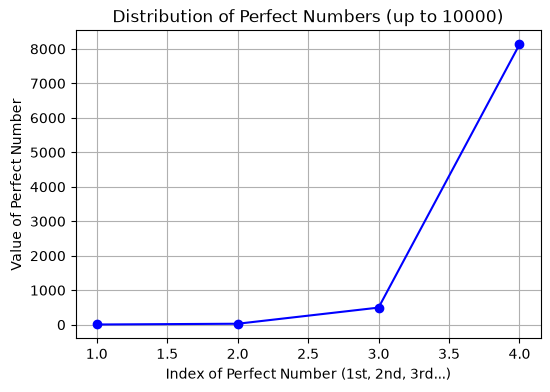

In [41]:
# Plot the distribution of perfect numbers
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(perfect_nums) + 1), perfect_nums, marker='o', color='blue', linestyle='-')
plt.title("Distribution of Perfect Numbers (up to 10000)")
plt.xlabel("Index of Perfect Number (1st, 2nd, 3rd...)")
plt.ylabel("Value of Perfect Number")
plt.grid(True)
plt.show()

> ⚠️ **Common mistakes**
>
> - Forgetting to initialize `s = 1` (since 1 divides every n).
> - Failing to check `i != n // i` before adding mirrored divisors.
> - Using `i <= n` instead of `i * i <= n`, causing redundant computation.
> - Returning an integer instead of a Boolean value.
>

## Task 5: π Approximation (Leibniz Series)

### Goals

Approximate the value of π using the Leibniz series. Implement a for loop to accumulate alternating terms and observe the convergence behavior as the number of terms increases.

### Learning objectives

- Understand the Leibniz formula for π approximation.
- Implement alternating summation using a for loop.
- Compute the absolute error against `math.pi`.
- Analyze the convergence rate as the number of terms increases.

### Theory

The Leibniz series provides a simple alternating series for π approximation:

**π = 4 × (1 − 1/3 + 1/5 − 1/7 + 1/9 − …)**

Each iteration alternates the sign and adds a new fractional term. Although it converges slowly, it is conceptually important for understanding numerical convergence.

### Pseudocode

```text
START
FUNCTION pi_leibniz(k_terms)
    SET sgn = 1
    SET acc = 0
    FOR k = 0 TO k_terms - 1
        acc = acc + sgn / (2*k + 1)
        sgn = sgn * -1
    END FOR
    RETURN 4 * acc
END FUNCTION

FOR each t in [100, 1000, 10000]:
    COMPUTE approx = pi_leibniz(t)
    COMPUTE error = abs(math.pi - approx)
    PRINT t, approx, error
END
```

### Python code

In [48]:
import math

def pi_leibniz(k_terms: int) -> float:
    sgn = 1.0
    acc = 0.0
    for k in range(k_terms):
        acc += sgn / (2 * k + 1)
        sgn *= -1
    return 4 * acc

for t in [100, 1000, 10000]:
    approx = pi_leibniz(t)
    print(f"terms={t:<6} π≈{approx:.6f} error={abs(math.pi - approx):.6f}")

terms=100    π≈3.131593 error=0.010000
terms=1000   π≈3.140593 error=0.001000
terms=10000  π≈3.141493 error=0.000100


```text
terms=100    π≈3.131593 error=0.010000
terms=1000   π≈3.140593 error=0.001000
terms=10000  π≈3.141493 error=0.000100
```

### Extended exercises

1. Allow user input for an error threshold ε and stop when `abs(math.pi - 4*acc) < ε`.
2. Plot the convergence curve (terms vs error) using matplotlib (log scale).
3. Compare with faster series (Nilakantha, Ramanujan).
4. Visualize the alternating signs (+1/1, −1/3, +1/5, …) with a bar chart.

In [44]:
# 1
import math

epsilon = float(input("Enter error threshold: "))

sgn = 1.0
acc = 0.0
k = 0

while abs(math.pi - 4 * acc) >= epsilon:
    acc += sgn / (2 * k + 1)
    sgn *= -1
    k += 1

approx_pi = 4 * acc
print(f"Reached threshold {epsilon} after {k} terms.")
print(f"Approximation: {approx_pi:.6f} | True Pi: {math.pi:.6f}")

Reached threshold 1e-05 after 100001 terms.
Approximation: 3.141603 | True Pi: 3.141593


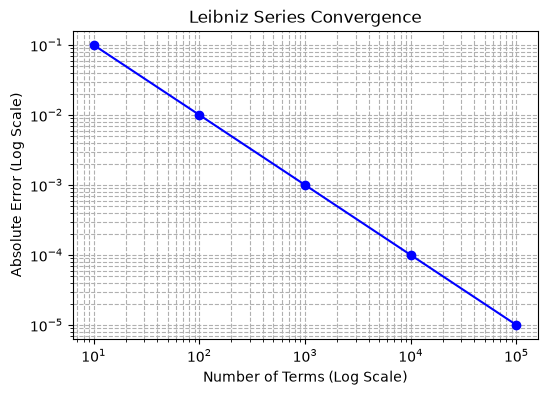

In [45]:
# 2
import matplotlib.pyplot as plt

def pi_leibniz(k_terms: int) -> float:
    sgn = 1.0
    acc = 0.0
    for k in range(k_terms):
        acc += sgn / (2 * k + 1)
        sgn *= -1
    return 4 * acc

terms_list = [10, 100, 1000, 10000, 100000]
errors = []

for t in terms_list:
    approx = pi_leibniz(t)
    errors.append(abs(math.pi - approx))

plt.figure(figsize=(6, 4))
plt.plot(terms_list, errors, marker='o', color='blue')
plt.xscale('log') 
plt.yscale('log') 
plt.title('Leibniz Series Convergence')
plt.xlabel('Number of Terms (Log Scale)')
plt.ylabel('Absolute Error (Log Scale)')
plt.grid(True, which="both", ls="--")
plt.show()

In [47]:
# 3
def pi_nilakantha(k_terms: int) -> float:
    if k_terms <= 0: return 3.0
    acc = 3.0
    sgn = 1.0
    for k in range(1, k_terms):
        d = 2 * k
        acc += sgn * (4.0 / (d * (d + 1) * (d + 2)))
        sgn *= -1
    return acc

test_terms = 50
leibniz_pi = pi_leibniz(test_terms)
nilakantha_pi = pi_nilakantha(test_terms)

print(f"Leibniz Error:    {abs(math.pi - leibniz_pi):.10f}")
print(f"Nilakantha Error: {abs(math.pi - nilakantha_pi):.10f}")
print("Conclusion: Nilakantha converges significantly faster.")

Leibniz Error:    0.0199980010
Nilakantha Error: 0.0000019990
Conclusion: Nilakantha converges significantly faster.


> ⚠️ **Common mistakes**
>
> - Using `range(1, k_terms+1)` but miscalculating the term indices (off by one).
> - Forgetting to multiply the result by 4.
> - Not flipping the sign correctly each iteration.
> - Using `int` instead of `float`, causing precision errors.
>

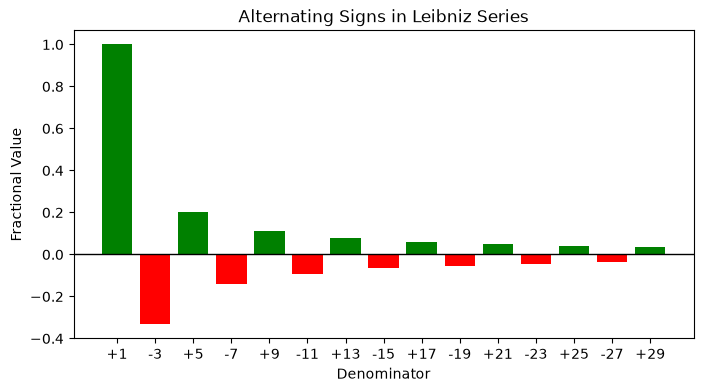

In [49]:
# 4
n_bars = 15
terms = []
labels = []

sgn = 1.0
for k in range(n_bars):
    term_val = sgn / (2 * k + 1)
    terms.append(term_val)
    labels.append(f"{'+' if sgn>0 else '-'}{2*k+1}")
    sgn *= -1

plt.figure(figsize=(8, 4))
plt.bar(range(n_bars), terms, color=['green' if t > 0 else 'red' for t in terms])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(range(n_bars), labels)
plt.title('Alternating Signs in Leibniz Series')
plt.xlabel('Denominator')
plt.ylabel('Fractional Value')
plt.show()

## Task 6: Fibonacci nth Term and Sequence

### Goals

Generate the Fibonacci sequence and find the nth Fibonacci number. Reinforce the use of for loops and tuple assignment, and compare iterative vs recursive logic.

### Learning objectives

- Understand the Fibonacci recurrence relation Fₙ = Fₙ₋₁ + Fₙ₋₂.
- Implement Fibonacci generation using an iterative for loop.
- Use a list comprehension to produce a sequence of terms.
- Explore growth patterns, ratios, and visualization extensions.

### Theory

The Fibonacci sequence starts with F₀ = 0, F₁ = 1, and each next term equals the sum of the two preceding terms. This sequence grows exponentially and appears in nature, finance, and AI pattern modeling. Iterative computation avoids recursion overhead and allows O(n) efficiency.

### Pseudocode

```text
START
FUNCTION fib(n)
    SET a = 0, b = 1
    FOR i = 0 TO n-1:
        SET temp = a
        a = b
        b = temp + b
    RETURN a
END FUNCTION

CREATE list seq = []
FOR i = 0 TO 9:
    APPEND fib(i) TO seq
PRINT seq
END
```

### Python code

In [ ]:
def fib(n: int) -> int:
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a

seq = [fib(i) for i in range(10)]
print(seq)

```text
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
```

### Extended exercises

- Allow user input: ask for n and print F(n).
- Display the ratios F(n)/F(n−1) to explore convergence to the Golden Ratio.
- Plot Fibonacci growth using matplotlib (x-axis: n, y-axis: F(n)).
- Compare iterative and recursive implementations and measure their speed.
- Apply modulo operations for pattern- or cryptography-based tasks.

In [2]:
# 1
def fib(n: int) -> int:
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a
user_n = int(input("Enter n to find the nth Fibonacci number: "))
print(f"F({user_n}) = {fib(user_n)}")

F(10) = 55


In [3]:
# 2
for i in range(2, 16):
    ratio = fib(i) / fib(i-1)
    print(f"F({i})/F({i-1}) = {ratio:.6f}")

F(2)/F(1) = 1.000000
F(3)/F(2) = 2.000000
F(4)/F(3) = 1.500000
F(5)/F(4) = 1.666667
F(6)/F(5) = 1.600000
F(7)/F(6) = 1.625000
F(8)/F(7) = 1.615385
F(9)/F(8) = 1.619048
F(10)/F(9) = 1.617647
F(11)/F(10) = 1.618182
F(12)/F(11) = 1.617978
F(13)/F(12) = 1.618056
F(14)/F(13) = 1.618026
F(15)/F(14) = 1.618037


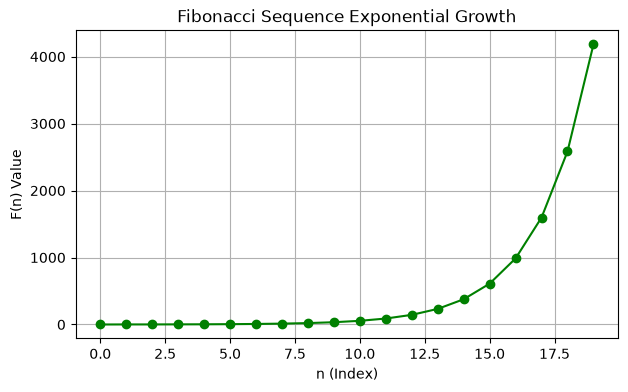

In [4]:
# 3
import matplotlib.pyplot as plt

n_vals = list(range(20))
fib_vals = [fib(i) for i in n_vals]

plt.figure(figsize=(7, 4))
plt.plot(n_vals, fib_vals, marker='o', color='green')
plt.title("Fibonacci Sequence Exponential Growth")
plt.xlabel("n (Index)")
plt.ylabel("F(n) Value")
plt.grid(True)
plt.show()

In [5]:
# 4
import time

def fib_recursive(n: int) -> int:
    if n <= 1:
        return n
    return fib_recursive(n-1) + fib_recursive(n-2)

test_n = 35 # Use a sufficiently large number to see the delay

# Test Iterative (Teacher's method)
start_time = time.time()
res_iter = fib(test_n)
iter_time = time.time() - start_time
print(f"Iterative Result: {res_iter} | Time: {iter_time:.6f} seconds")

# Test Recursive (Naive method)
start_time = time.time()
res_rec = fib_recursive(test_n)
rec_time = time.time() - start_time
print(f"Recursive Result: {res_rec} | Time: {rec_time:.6f} seconds")
print(f"Iterative is faster by {rec_time - iter_time:.6f} seconds!")

Iterative Result: 9227465 | Time: 0.000103 seconds
Recursive Result: 9227465 | Time: 2.450926 seconds
Iterative is faster by 2.450823 seconds!


In [6]:
# 5
mod_val = 10
seq_length = 20
mod_sequence = [fib(i) % mod_val for i in range(seq_length)]

print("Standard Seq:", [fib(i) for i in range(seq_length)])
print(f"Modulo {mod_val} Seq: ", mod_sequence)

Standard Seq: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]
Modulo 10 Seq:  [0, 1, 1, 2, 3, 5, 8, 3, 1, 4, 5, 9, 4, 3, 7, 0, 7, 7, 4, 1]


> 🎓 **Scholar discussion**
>
> The Fibonacci sequence exemplifies linear recursion and exponential growth. The ratio F(n+1)/F(n) approaches the Golden Ratio φ ≈ 1.618, seen in natural and financial systems. The iterative implementation (O(n)) is efficient compared to the naive recursive one (O(2ⁿ)), and the logic aligns with predictive models in time-series and machine learning.
>

> ⚠️ **Common mistakes**
>
> - Reversing the update order of `a` and `b`.
> - Using recursion without base cases (causes infinite recursion).
> - Incorrect range in the list comprehension (missing the first element).
> - Forgetting to initialize `a, b = 0, 1` properly.
>

## Task 7: Binary to Decimal (Positional Weights)

### Goals

Understand how to convert binary numbers to decimal using positional weights. Practice looping through string bits and accumulating positional values.

### Learning objectives

- Explain the concept of positional weights in binary representation.
- Implement binary-to-decimal conversion using iterative accumulation.
- Compare manual computation with Python's built-in `int(bits, 2)`.
- Extend the concept to other numeral systems (octal, hexadecimal).

### Theory

In a binary number, each bit has a positional weight that is a power of two. For example, 1101₂ = 1×2³ + 1×2² + 0×2¹ + 1×2⁰ = 13₁₀. The iterative approach multiplies the accumulated value by 2 and adds 1 if the current bit is `'1'`.

### Pseudocode

```text
START
FUNCTION bin_to_dec(bits)
    SET val = 0
    FOR each character ch in bits:
        IF ch == '1' THEN
            val = val * 2 + 1
        ELSE
            val = val * 2 + 0
    END FOR
    RETURN val
END FUNCTION

PRINT bin_to_dec('1101')
END
```

### Python code

In [ ]:
def bin_to_dec(bits: str) -> int:
    val = 0
    for ch in bits:
        val = val * 2 + (1 if ch == '1' else 0)
    return val

print(bin_to_dec('1101'))

```text
13
```

### Extended exercises

- Allow user input and validate the binary string.
- Compare the result with `int(bits, 2)`.
- Implement the reverse conversion (decimal to binary).
- Handle invalid input gracefully (non-binary characters).
- Plot bit positions and powers of 2 using matplotlib.

In [60]:
# 1
def bin_to_dec(bits: str) -> int:
    val = 0
    for ch in bits:
        val = val * 2 + (1 if ch == '1' else 0)
    return val
user_bits = input("Enter a binary string: ")
dec_val = bin_to_dec(user_bits)
print(f"Binary '{user_bits}' to Decimal: {dec_val}")

Binary '1101' to Decimal: 13


In [61]:
# 2
builtin_val = int(user_bits, 2)
print(f"Built-in int('{user_bits}', 2) result: {builtin_val}")
print(f"Match? {dec_val == builtin_val}")

Built-in int('1101', 2) result: 13
Match? True


In [62]:
# 3
def dec_to_bin(n: int) -> str:
    if n == 0:
        return "0"
    
    bits = ""
    while n > 0:
        bits = str(n % 2) + bits 
        n = n // 2
    return bits

test_dec = 13
print(f"Decimal {test_dec} to Binary string: '{dec_to_bin(test_dec)}'")

Decimal 13 to Binary string: '1101'


In [64]:
# 4
while True:
    valid_bits = input("Enter a binary string: ")
    if valid_bits != "" and all(c in '01' for c in valid_bits):
        break
    print("Invalid input! Please enter only '0' or '1'.")

result = bin_to_dec(valid_bits)
print(f"Validated Binary '{valid_bits}' to Decimal: {result}")

Validated Binary '1101' to Decimal: 13


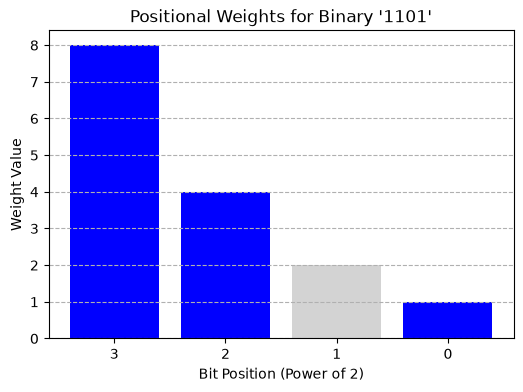

In [65]:
# 5
import matplotlib.pyplot as plt

bits_str = '1101'
length = len(bits_str)

positions = list(range(length - 1, -1, -1))
powers = [2 ** p for p in positions]

colors = ['blue' if b == '1' else 'lightgray' for b in bits_str]

plt.figure(figsize=(6, 4))
plt.bar([str(p) for p in positions], powers, color=colors)
plt.title(f"Positional Weights for Binary '{bits_str}'")
plt.xlabel("Bit Position (Power of 2)")
plt.ylabel("Weight Value")
plt.grid(axis='y', linestyle='--')
plt.show()

> ⚠️ **Common mistakes**
>
> - Processing bits in reverse order (right-to-left) incorrectly.
> - Forgetting to multiply by 2 before adding the current bit.
> - Not checking for invalid characters (anything other than `'0'` or `'1'`).
> - Assuming the input is an integer instead of a string.
>

# <font color="#C00000">5. Exercises</font>

<font color="#C00000">Solve these without looking at a solution first. For each task: (1) write the pseudocode, (2) write the program, (3) run it with the sample input and with your own test cases.</font>

## <font color="#C00000">Task 8 – Prime number checker and prime list</font>

<font color="#C00000">Write a function `is_prime(n)` that returns `True` if n is prime. Use a `while` loop that tests divisors only up to √n (as in Task 4). Then print all primes below 100, ten per line, right-aligned in width 4, and the number of primes found.</font>

<font color="#C00000">*(added)*</font>
```text
   2   3   5   7  11  13  17  19  23  29
  31  37  41  43  47  53  59  61  67  71
  73  79  83  89  97
25 primes below 100
```

In [ ]:
# [ADDED] starter code – complete the TODOs
def is_prime(n: int) -> bool:
    if n < 2:
        return False
    i = 2
    while i * i <= n:
        # TODO: return False if i divides n
        i += 1
    return True

count = 0
for n in range(2, 100):
    if is_prime(n):
        # TODO: print n in width 4 without a newline; start a new line after 10 primes
        count += 1
print()
print(count, "primes below 100")

In [66]:
def is_prime(n: int) -> bool:
    if n < 2:
        return False
    i = 2
    while i * i <= n:
        # TODO: return False if i divides n
        if n % i == 0:
            return False
        i += 1
    return True

count = 0
for n in range(2, 100):
    if is_prime(n):
        # TODO: print n in width 4 without a newline; start a new line after 10 primes
        print(f"{n:>4}", end="")
        count += 1
        
        # Start a new line after exactly 10 primes
        if count % 10 == 0:
            print()

# Ensure the final count prints on a new line if the last row didn't perfectly hit 10 items
if count % 10 != 0:
    print()

print(count, "primes below 100")

   2   3   5   7  11  13  17  19  23  29
  31  37  41  43  47  53  59  61  67  71
  73  79  83  89  97
25 primes below 100


## <font color="#C00000">Task 9 – GCD and LCM with Euclid's algorithm</font>

<font color="#C00000">The greatest common divisor satisfies gcd(a, b) = gcd(b, a % b) and gcd(a, 0) = a. Write `gcd(a, b)` with a `while` loop (no `math.gcd`), print every step, and compute lcm(a, b) = a × b // gcd(a, b). Check your result with `math.gcd`.</font>

<font color="#C00000">*(added)*</font>
```text
a = 84, b = 36
84 % 36 = 12
36 % 12 = 0
gcd = 12, lcm = 252
```

In [67]:
import math

def gcd_euclid(a: int, b: int) -> int:
    print(f"a={a} b={b}")
    while b != 0:
        rem = a % b
        print(f"{a} % {b} = {rem}")
        a, b = b, rem
    return a

a_val = 84
b_val = 36

gcd_val = gcd_euclid(a_val, b_val)

lcm_val = (a_val * b_val) // gcd_val

print(f"gcd={gcd_val} lcm={lcm_val}")

check_gcd = math.gcd(a_val, b_val)
print(f"Check with math.gcd: {check_gcd} == {gcd_val} is {check_gcd == gcd_val}")

a=84 b=36
84 % 36 = 12
36 % 12 = 0
gcd=12 lcm=252
Check with math.gcd: 12 == 12 is True


## <font color="#C00000">Task 10 – Collatz sequence (while loop)</font>

<font color="#C00000">Start from a positive integer n. If n is even, n ← n // 2; otherwise n ← 3n + 1. Repeat until n = 1. Print the sequence and the number of steps. Then find the starting value below 1000 with the longest sequence.</font>

<font color="#C00000">*(added)*</font>
```text
n = 6: 6 3 10 5 16 8 4 2 1  (8 steps)
Longest below 1000: n = 871 with 178 steps
```

In [68]:
def collatz(n: int):
    sequence = [n]
    steps = 0
    while n > 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        sequence.append(n)
        steps += 1
    return sequence, steps

test_n = 6
seq, stp = collatz(test_n)
print(f"n = {test_n}:", *seq, f"({stp} steps)")

max_steps = 0
best_start = 0

for i in range(1, 1000):
    _, stp = collatz(i)
    if stp > max_steps:
        max_steps = stp
        best_start = i

print(f"Longest below 1000: n = {best_start} with {max_steps} steps")

n = 6: 6 3 10 5 16 8 4 2 1 (8 steps)
Longest below 1000: n = 871 with 178 steps


# 6. Submission Instructions

## What to submit

1. **Source code folder (/codes/)** – each task should be implemented in a separate `.py` file:

```text
codes/
├── task1_weekly_flu.py
├── task2_hms_peeling.py
├── task3_wage_growth.py
├── task4_perfect_number.py
└── ...
```

Each file must contain a header comment with student info:

```python
# Student Name:
# Student ID:
# Course: Fundamentals of Programming (FoP)
# Lab 2 – Task X
# Date:
# Description: Short summary of the task
```

Ensure each script runs correctly and includes inline comments for clarity.

2. **Output evidence folder (/outputs/)** – include screenshots of successful runs for each task (`task1_output.png` … `task7_output.png`). Screenshots must clearly show the input, output, and any charts produced.
3. **Lab report (FoP_Lab2_Report.docx or .pdf)** – your report must include: cover page (name, student ID, course, semester, submission date); table of contents; Tasks 1–7 <font color="#C00000">(and 8–10)</font>; summary: what you learned.
4. **Submission format** – the final submission is one folder (or ZIP) named `IT149IU_Lab2_FullName_StudentID` containing `codes/`, `outputs/`, `FoP_Lab2_Report.docx` and `README.txt`.

## <font color="#C00000">How to submit (Google Form)</font>

<font color="#C00000">All labs are submitted through **one shared Google Form**. Submit a **link** to a folder or repository that contains your work.</font>

<font color="#C00000">**Step 1 – Organize your work** in one folder named `IT149IU_Lab2_FullName_StudentID` (e.g. `IT149IU_Lab2_NguyenVanAn_ITITIU24001`):</font>

<font color="#C00000">*(added)*</font>
```text
IT149IU_Lab2_FullName_StudentID/
├── FoP_Lab2_FullName_StudentID.ipynb
├── codes/
│   ├── Task1.py
│   └── ...
├── outputs/
│   ├── task1_output.png
│   └── ...
├── FoP_Lab2_Report.pdf
└── README.md
```

- <font color="#C00000">the **notebook** – completed, with all cells executed;</font>
- <font color="#C00000">**codes/** – one `.py` file per task, each starting with the header comment;</font>
- <font color="#C00000">**outputs/** – screenshots that clearly show input and output;</font>
- <font color="#C00000">the **lab report** (.docx or .pdf) and a **README.md** (name, student ID, how to run, notes).</font>

<font color="#C00000">**Step 2 – Upload the folder** using ONE of these options:</font>

1. <font color="#C00000">**GitHub (recommended):** create a repository (e.g. `IT149IU-FoP-Labs`, one sub-folder per lab), push your files and make the repository *Public* (or add the instructor as a collaborator).</font>
2. <font color="#C00000">**Google Drive:** upload the folder → right-click → *Share* → *General access: Anyone with the link – Viewer* → *Copy link*.</font>
3. <font color="#C00000">**Google Colab only:** *Share* → *Anyone with the link – Viewer* → *Copy link* (use this only if all work is inside the notebook).</font>

<font color="#C00000">*(added)*</font>
```bash
# GitHub from the command line (first time)
git init
git add .
git commit -m "Lab 2 – FullName – StudentID"
git branch -M main
git remote add origin https://github.com/<your-username>/IT149IU-FoP-Labs.git
git push -u origin main
# later labs: git add . ; git commit -m "Lab N" ; git push
```

<font color="#C00000">**Step 3 – Submit the link in the Google Form**</font>

| <font color="#C00000">Item</font> | <font color="#C00000">Details</font> |
|---|---|
| <font color="#C00000">Submission form for **Lab 2** (Lab number pre-selected)</font> | <font color="#C00000">[Open the Lab 2 submission form](https://docs.google.com/forms/d/e/1FAIpQLSfCz6lyUsunGqohV90ijKKRqbGljc4b9GRj3K-ExsIJu5WOJA/viewform?usp=pp_url&entry.1269823331=Lab+2)</font> |
| <font color="#C00000">Short link (choose "Lab 2" in the form)</font> | <font color="#C00000">https://forms.gle/aHqDLDZ6YUyzoYVv8</font> |
| <font color="#C00000">Fields to fill in</font> | <font color="#C00000">Full name · Student ID · Class/Group · Lab number · Submission type · Submission link</font> |
| <font color="#C00000">Deadline</font> | <font color="#C00000">End of the lab week – Sunday 23:59 (unless the instructor announces another date)</font> |

<font color="#C00000">**Before you press Submit – checklist**</font>

- <font color="#C00000">The notebook runs from top to bottom without errors (*Runtime → Restart session and run all*).</font>
- <font color="#C00000">Every task has code, output (screenshot or cell output) and, where requested, pseudocode.</font>
- <font color="#C00000">Each `.py` file starts with the header comment (name, ID, course, lab, task, date, description).</font>
- <font color="#C00000">The link opens in a private/incognito browser window (sharing permission is correct).</font>
- <font color="#C00000">You may re-submit (edit your response) before the deadline; the last submission is graded.</font>

> 📌 **Note** — **<font color="#C00000">Grading guide (per lab)</font>**
>
> | <font color="#C00000">Criterion</font> | <font color="#C00000">Weight</font> |
> |---|---|
> | <font color="#C00000">Correctness of programs (all required tasks)</font> | <font color="#C00000">50%</font> |
> | <font color="#C00000">Pseudocode / algorithm and explanation</font> | <font color="#C00000">15%</font> |
> | <font color="#C00000">Code quality (names, comments, functions, input validation)</font> | <font color="#C00000">15%</font> |
> | <font color="#C00000">Output evidence (screenshots / executed notebook)</font> | <font color="#C00000">10%</font> |
> | <font color="#C00000">Extensions and challenge tasks</font> | <font color="#C00000">10%</font> |
>

> ⚠️ **Common mistakes** — **<font color="#C00000">Academic integrity</font>**
>
> <font color="#C00000">Discuss ideas with classmates, but write your own code. Copied submissions receive zero for all students involved. If you use an AI assistant, state which tool and for which part in the *Notes* field of the form and in your README.</font>
>